# Coreference Chain Exploration — LitBank

**Dataset:** [`coref-data/litbank_raw`](https://huggingface.co/datasets/coref-data/litbank_raw) (CC-BY-4.0)

LitBank is a coreference resolution corpus of 100 English literary works annotated with entity mentions and coreference chains. Each document comes pre-tokenized and contains:

- `sentences` — tokenized sentences as `List[List[str]]`
- `coref_chains` — clusters of mentions, each mention as `[sentence_id, start_token, end_token]` (0-based, inclusive)
- `meta_info` — author, title, Gutenberg ID

> **Note:** `tner/ontonotes5` only contains NER labels. This dataset is the appropriate free alternative for coreference chain work.

## 1. Imports

In [33]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from IPython.display import HTML, display
import random
import textwrap

## 2. Load the Dataset

In [34]:
# LitBank has 10 cross-validation splits (split_0 through split_9)
# We use split_0 which contains ~90 training + ~10 test documents
dataset = load_dataset("coref-data/litbank_raw", "split_0")
print(dataset)
print(f"\nTrain docs : {len(dataset['train'])}")
print(f"\nValidation docs : {len(dataset['validation'])}")
print(f"\nTest docs  : {len(dataset['test'])}")

DatasetDict({
    train: Dataset({
        features: ['doc_name', 'meta_info', 'sentences', 'coref_chains', 'entities', 'events', 'original_text', 'quotes'],
        num_rows: 80
    })
    validation: Dataset({
        features: ['doc_name', 'meta_info', 'sentences', 'coref_chains', 'entities', 'events', 'original_text', 'quotes'],
        num_rows: 10
    })
    test: Dataset({
        features: ['doc_name', 'meta_info', 'sentences', 'coref_chains', 'entities', 'events', 'original_text', 'quotes'],
        num_rows: 10
    })
})

Train docs : 80

Validation docs : 10

Test docs  : 10


## 3. Inspect a Single Document

In [35]:
doc = dataset["train"][0]

meta   = doc["meta_info"]
print("Meta: ", meta)

print(f"Title  : {meta['title']}")
print(f"Author : {meta['author']}")
print(f"Date   : {meta['date']}")

Meta:  {'author': 'Melville, Herman', 'date': '1851', 'gutenberg_id': '2489', 'title': 'Moby Dick; Or, The Whale'}
Title  : Moby Dick; Or, The Whale
Author : Melville, Herman
Date   : 1851


In [36]:
sents  = doc["sentences"]
chains = doc["coref_chains"]

print(f"\nNumber of sentences   : {len(sents)}")
print(f"Number of coref chains: {len(chains)}")


Number of sentences   : 94
Number of coref chains: 175


In [37]:
sents[0]

['CHAPTER', '1', 'Loomings', 'Call', 'me', 'Ishmael', '.']

In [38]:
chains[0]

[[0, 4, 4],
 [0, 5, 5],
 [1, 16, 16],
 [1, 24, 24],
 [1, 28, 28],
 [1, 30, 30],
 [2, 4, 4],
 [3, 1, 1],
 [3, 3, 3],
 [3, 19, 19],
 [3, 19, 20],
 [3, 23, 23],
 [3, 25, 25],
 [3, 40, 40],
 [3, 46, 46],
 [3, 54, 54],
 [3, 65, 65],
 [3, 83, 83],
 [3, 95, 95],
 [4, 2, 2],
 [5, 11, 11],
 [7, 28, 28],
 [31, 1, 1],
 [57, 3, 3],
 [57, 6, 6],
 [57, 16, 16],
 [57, 32, 32],
 [57, 35, 35],
 [57, 44, 44],
 [59, 29, 29],
 [59, 39, 39],
 [59, 47, 47],
 [60, 0, 0],
 [61, 1, 1],
 [61, 4, 4],
 [62, 6, 6],
 [62, 13, 13],
 [63, 9, 9],
 [63, 32, 32],
 [63, 72, 72],
 [65, 3, 3],
 [65, 8, 8],
 [66, 5, 5],
 [66, 11, 11],
 [70, 7, 7],
 [72, 12, 12],
 [73, 9, 9],
 [74, 11, 11],
 [74, 14, 14],
 [76, 1, 1],
 [77, 10, 10],
 [77, 19, 19],
 [77, 22, 22],
 [78, 2, 2],
 [78, 18, 18],
 [78, 20, 20],
 [78, 32, 32],
 [86, 2, 2],
 [90, 16, 16],
 [90, 22, 22],
 [90, 46, 46],
 [90, 51, 51],
 [90, 55, 55],
 [91, 4, 4],
 [93, 0, 0]]

In [39]:
print(f"\n--- First 3 sentences ---")
for i, sent in enumerate(sents[:3]):
    print(f"  [{i}] {' '.join(sent)}")


--- First 3 sentences ---
  [0] CHAPTER 1 Loomings Call me Ishmael .
  [1] Some years ago -- never mind how long precisely -- having little or no money in my purse , and nothing particular to interest me on shore , I thought I would sail about a little and see the watery part of the world .
  [2] It is a way I have of driving off the spleen and regulating the circulation .


## 4. Decode a Coreference Chain

Each chain is a list of mentions. Each mention is `[sentence_id, start_token, end_token]`.

In [40]:
def resolve_mention(sentences, mention):
    """Return the surface string for a mention [sent_id, start, end]."""
    sent_id, start, end = mention
    return " ".join(sentences[sent_id][start : end + 1])

In [41]:

def print_chain(sentences, chain, chain_idx):
    print(f"Chain #{chain_idx}  ({len(chain)} mentions)")
    for mention in chain:
        sent_id, start, end = mention
        surface = resolve_mention(sentences, mention)
        context = " ".join(sentences[sent_id])
        print(f"  sent={sent_id:3d} tok=[{start},{end}]  '{surface}'")
        print(f"         context: ...{context[:80]}...")
    print()

In [42]:
# Print the 3 longest chains in this document
sorted_chains = sorted(enumerate(chains), key=lambda x: len(x[1]), reverse=True)
for chain_idx, chain in sorted_chains[:3]:
    print_chain(sents, chain, chain_idx)

Chain #0  (65 mentions)
  sent=  0 tok=[4,4]  'me'
         context: ...CHAPTER 1 Loomings Call me Ishmael ....
  sent=  0 tok=[5,5]  'Ishmael'
         context: ...CHAPTER 1 Loomings Call me Ishmael ....
  sent=  1 tok=[16,16]  'my'
         context: ...Some years ago -- never mind how long precisely -- having little or no money in ...
  sent=  1 tok=[24,24]  'me'
         context: ...Some years ago -- never mind how long precisely -- having little or no money in ...
  sent=  1 tok=[28,28]  'I'
         context: ...Some years ago -- never mind how long precisely -- having little or no money in ...
  sent=  1 tok=[30,30]  'I'
         context: ...Some years ago -- never mind how long precisely -- having little or no money in ...
  sent=  2 tok=[4,4]  'I'
         context: ...It is a way I have of driving off the spleen and regulating the circulation ....
  sent=  3 tok=[1,1]  'I'
         context: ...Whenever I find myself growing grim about the mouth ; whenever it is a damp , dr...
  

## 5. Visualise Mention Positions Across the Document

Each row = one coreference chain. Each dot = one mention, positioned by sentence index.

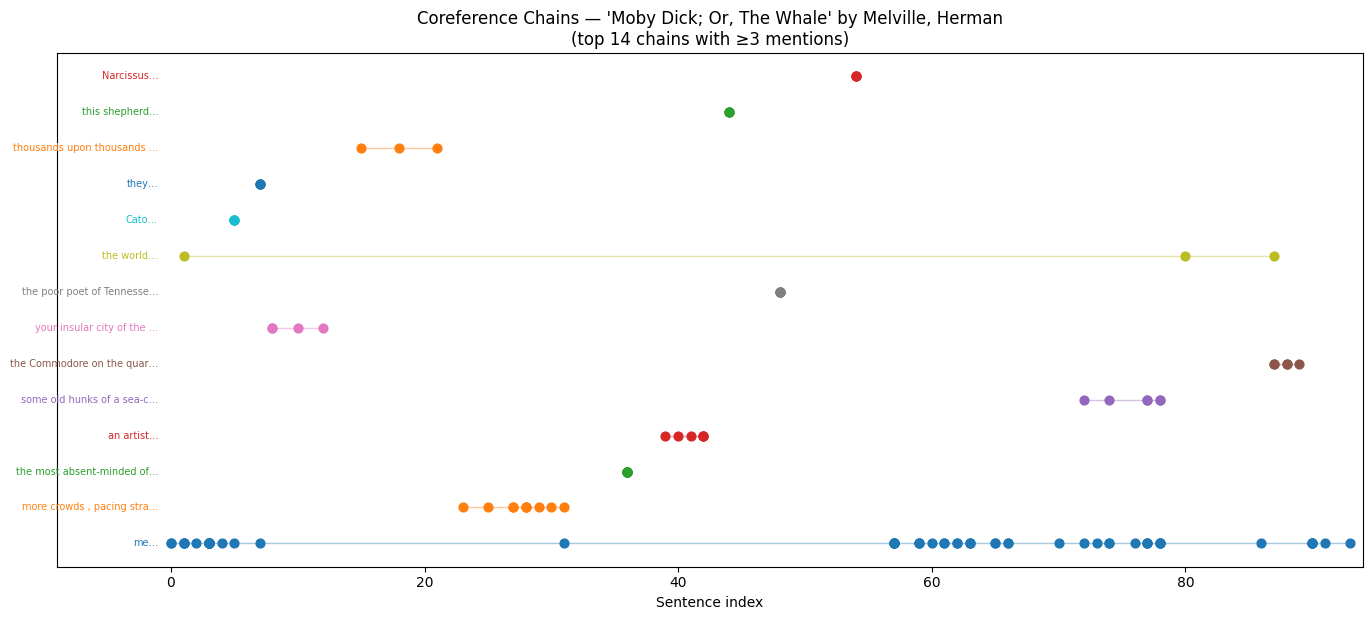

In [43]:
# Show only chains with ≥ 3 mentions to keep the plot readable
long_chains = [(i, c) for i, c in enumerate(chains) if len(c) >= 3]
long_chains_sorted = sorted(long_chains, key=lambda x: len(x[1]), reverse=True)[:20]

palette = list(mcolors.TABLEAU_COLORS.values())

fig, ax = plt.subplots(figsize=(14, max(4, len(long_chains_sorted) * 0.45)))

for row_idx, (chain_idx, chain) in enumerate(long_chains_sorted):
    color = palette[row_idx % len(palette)]
    sent_positions = [m[0] for m in chain]
    label = resolve_mention(sents, chain[0])[:25]

    # Draw a line connecting the mentions
    ax.plot(sent_positions, [row_idx] * len(sent_positions),
            "-", color=color, alpha=0.4, linewidth=1)
    ax.scatter(sent_positions, [row_idx] * len(sent_positions),
               color=color, s=40, zorder=3)
    ax.text(-1, row_idx, f"{label}…", ha="right", va="center", fontsize=7, color=color)

ax.set_xlabel("Sentence index")
ax.set_yticks([])
ax.set_title(
    f"Coreference Chains — '{meta['title']}' by {meta['author']}\n"
    f"(top {len(long_chains_sorted)} chains with ≥3 mentions)"
)
ax.set_xlim(-len(max([c for _, c in long_chains_sorted], key=lambda c: resolve_mention(sents, c[0])).__class__.__name__) - 5, len(sents))
plt.tight_layout()
plt.show()

## 6. HTML Span Visualisation

Highlight mentions inline in the text, coloured by coreference chain, for the first few sentences.

In [44]:
NUM_SENTENCES = 15  # how many sentences to render

# Build a lookup: (sent_id, tok_idx) -> (chain_idx, is_start, is_end)
mention_map = {}  # (sent_id, tok_idx) -> list of (chain_idx, start, end)
for chain_idx, chain in enumerate(chains):
    for mention in chain:
        sent_id, start, end = mention
        if sent_id >= NUM_SENTENCES:
            continue
        for tok in range(start, end + 1):
            mention_map.setdefault((sent_id, tok), []).append(
                (chain_idx, tok == start, tok == end)
            )

COLORS_HEX = [
    "#AED6F1", "#A9DFBF", "#F9E79F", "#F1948A", "#D7BDE2",
    "#FAD7A0", "#A2D9CE", "#F0B27A", "#85C1E9", "#82E0AA",
]

html_parts = ["<div style='font-family:monospace;line-height:1.9;font-size:14px'>"]
for sent_id, sent in enumerate(sents[:NUM_SENTENCES]):
    html_parts.append(f"<span style='color:#888;margin-right:6px'>[{sent_id}]</span>")
    for tok_idx, token in enumerate(sent):
        key = (sent_id, tok_idx)
        if key in mention_map:
            # Use the first chain that covers this token for colouring
            chain_idx, is_start, is_end = mention_map[key][0]
            color = COLORS_HEX[chain_idx % len(COLORS_HEX)]
            border_left  = "border-left:2px solid #333;padding-left:2px;" if is_start else ""
            border_right = "border-right:2px solid #333;padding-right:2px;" if is_end else ""
            html_parts.append(
                f"<span style='background:{color};{border_left}{border_right}' "
                f"title='chain {chain_idx}'>{token}</span> "
            )
        else:
            html_parts.append(f"{token} ")
    html_parts.append("<br>")
html_parts.append("</div>")

display(HTML("".join(html_parts)))

## 7. Corpus-Level Statistics

In [45]:
rows = []
for split_name in ["train", "test"]:
    for doc in dataset[split_name]:
        n_chains   = len(doc["coref_chains"])
        n_mentions = sum(len(c) for c in doc["coref_chains"])
        n_sents    = len(doc["sentences"])
        rows.append({
            "split"     : split_name,
            "title"     : doc["meta_info"]["title"][:40],
            "sentences" : n_sents,
            "chains"    : n_chains,
            "mentions"  : n_mentions,
            "avg_chain_len": round(n_mentions / n_chains, 2) if n_chains else 0,
        })

stats_df = pd.DataFrame(rows)
print(stats_df.groupby("split")[["sentences", "chains", "mentions", "avg_chain_len"]].describe().T)
stats_df.head(10)

split                      test       train
sentences     count   10.000000   80.000000
              mean    88.000000   84.437500
              std     37.055514   28.045101
              min     46.000000   28.000000
              25%     60.750000   62.000000
              50%     79.500000   81.000000
              75%    104.500000  107.500000
              max    172.000000  179.000000
chains        count   10.000000   80.000000
              mean    80.700000   79.300000
              std     26.549953   28.124677
              min     49.000000   28.000000
              25%     60.000000   60.000000
              50%     81.000000   72.500000
              75%     93.750000   95.250000
              max    136.000000  175.000000
mentions      count   10.000000   80.000000
              mean   283.200000  290.225000
              std     41.856368   53.417386
              min    219.000000  131.000000
              25%    261.500000  252.500000
              50%    284.500000 

,split,title,sentences,chains,mentions,avg_chain_len
0,train,"Moby Dick; Or, The Whale",94,175,300,1.71
1,train,Middlemarch,48,92,256,2.78
2,train,"Bartleby, the Scrivener: A Story of Wall",91,69,306,4.43
3,train,The Circular Staircase,68,104,305,2.93
4,train,Piccadilly Jim,125,61,299,4.90
5,train,Persuasion,45,72,286,3.97
6,train,Charlotte Temple,59,65,310,4.77
7,train,King Solomon's Mines,78,91,301,3.31
8,train,The Turn of the Screw,121,54,269,4.98
9,train,A Princess of Mars,53,68,297,4.37


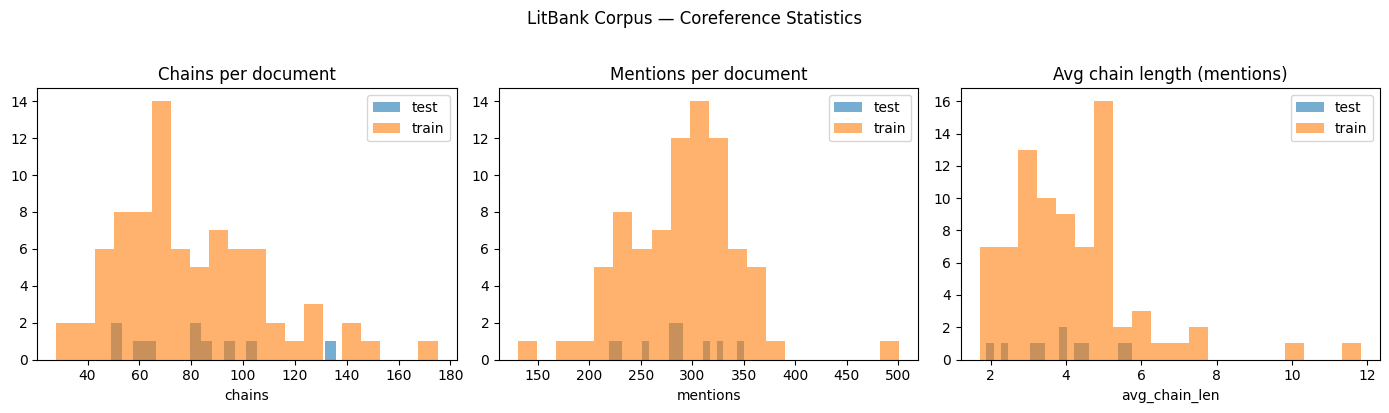

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ["chains", "mentions", "avg_chain_len"],
    ["Chains per document", "Mentions per document", "Avg chain length (mentions)"],
):
    for split, grp in stats_df.groupby("split"):
        ax.hist(grp[col], bins=20, alpha=0.6, label=split)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle("LitBank Corpus — Coreference Statistics", y=1.02)
plt.tight_layout()
plt.show()

## 8. Character-Based Chunking & Evaluation Metrics

We evaluate three chunking quality metrics defined in `metrics.py`:

| Metric | Definition |
|--------|------------|
| **Cluster Break Rate** | # chains spanning multiple chunks / # total chains |
| **Edge Cut Rate** | # consecutive mention-pairs crossing a chunk boundary / # total edges |
| **Entity Concentration** | (1/K) · Σ_k (most-mentioned entity in chunk k / total mentions in chunk k) |

**Chunking strategy:** the tokenised sentences are flattened into a single character stream and split into fixed-size windows of `chunk_size` characters.  
This makes the metrics format-agnostic — the same code works for any dataset, not just those pre-segmented by sentence.

In [50]:
import sys, os, importlib
# REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
# if REPO_ROOT not in sys.path:
#     sys.path.insert(0, REPO_ROOT)

import metrics as _metrics_mod
importlib.reload(_metrics_mod)

from metrics import (
    cluster_break_rate,
    edge_cut_rate,
    entity_concentration,
    build_mention_chunks_char,
    chunk_text,
)

In [51]:
def compute_metrics(mention_chunks, total_chunks) -> dict:
    return {
        "cluster_break_rate"   : cluster_break_rate(mention_chunks),
        "edge_cut_rate"        : edge_cut_rate(mention_chunks),
        "entity_concentration" : entity_concentration(mention_chunks, total_chunks),
    }

### Single document — metrics at one chunk size

In [52]:
CHUNK_SIZE = 100

In [54]:
CHUNK_SIZE = 100
doc = dataset["train"][0]

# --- chunk the flat text ---
chunks = chunk_text(doc["sentences"], CHUNK_SIZE)
mention_chunks, total_chunks = build_mention_chunks_char(
    doc["coref_chains"], doc["sentences"], CHUNK_SIZE
)

In [56]:
mention_chunks[:5]

[[0,
  0,
  1,
  1,
  1,
  1,
  2,
  3,
  3,
  4,
  4,
  4,
  4,
  5,
  5,
  6,
  6,
  7,
  8,
  8,
  9,
  11,
  27,
  55,
  55,
  55,
  56,
  56,
  57,
  60,
  60,
  60,
  61,
  62,
  62,
  63,
  63,
  64,
  66,
  68,
  70,
  70,
  71,
  72,
  77,
  79,
  80,
  81,
  81,
  82,
  83,
  83,
  83,
  86,
  87,
  87,
  88,
  94,
  100,
  100,
  102,
  102,
  102,
  103,
  105],
 [1],
 [2],
 [2, 89, 95],
 [4]]

In [55]:

# --- metrics ---
result = compute_metrics(mention_chunks, total_chunks)
print(f"Document     : {doc['meta_info']['title']}")
print(f"Chunk size   : {CHUNK_SIZE} characters")
print(f"Total chunks : {total_chunks}")
print()
print(f"Cluster Break Rate    : {result['cluster_break_rate']:.3f}")
print(f"Edge Cut Rate         : {result['edge_cut_rate']:.3f}")
print(f"Entity Concentration  : {result['entity_concentration']:.3f}")

# --- build a lookup: chunk_id -> [(chain_idx, mention_surface)] ---
chunk_mentions: dict[int, list[tuple[int, str]]] = {i: [] for i in range(total_chunks)}
for chain_idx, (chain, cids) in enumerate(zip(doc["coref_chains"], mention_chunks)):
    for mention, cid in zip(chain, cids):
        sent_id, start_tok, end_tok = mention
        surface = " ".join(doc["sentences"][sent_id][start_tok : end_tok + 1])
        chunk_mentions[cid].append((chain_idx, surface))

# --- print the first N chunks with their text and mentions ---
N_SHOW = 5
print(f"\n{'='*60}")
print(f"First {N_SHOW} chunks")
print(f"{'='*60}")
for i in range(min(N_SHOW, total_chunks)):
    mentions_in_chunk = chunk_mentions[i]
    print(f"\nChunk {i}  ({len(chunks[i])} chars, {len(mentions_in_chunk)} mention(s))")
    print(f"  Text : {repr(chunks[i])}")
    if mentions_in_chunk:
        for chain_idx, surface in mentions_in_chunk:
            print(f"  Mention: '{surface}'  (chain {chain_idx})")

Document     : Moby Dick; Or, The Whale
Chunk size   : 100 characters
Total chunks : 107

Cluster Break Rate    : 0.131
Edge Cut Rate         : 0.592
Entity Concentration  : 0.559

First 5 chunks

Chunk 0  (100 chars, 2 mention(s))
  Text : 'CHAPTER 1 Loomings Call me Ishmael . Some years ago -- never mind how long precisely -- having littl'
  Mention: 'me'  (chain 0)
  Mention: 'Ishmael'  (chain 0)

Chunk 1  (100 chars, 5 mention(s))
  Text : 'e or no money in my purse , and nothing particular to interest me on shore , I thought I would sail '
  Mention: 'my'  (chain 0)
  Mention: 'me'  (chain 0)
  Mention: 'I'  (chain 0)
  Mention: 'I'  (chain 0)
  Mention: 'shore'  (chain 1)

Chunk 2  (100 chars, 3 mention(s))
  Text : 'about a little and see the watery part of the world . It is a way I have of driving off the spleen a'
  Mention: 'I'  (chain 0)
  Mention: 'the watery part of the world'  (chain 2)
  Mention: 'the world'  (chain 3)

Chunk 3  (100 chars, 2 mention(s))
  Text : 'nd reg

In [57]:
print(f"Document  : {doc['meta_info']['title']}")
print()
print(f"Cluster Break Rate    : {result['cluster_break_rate']:.3f}")
print(f"Edge Cut Rate         : {result['edge_cut_rate']:.3f}")
print(f"Entity Concentration  : {result['entity_concentration']:.3f}")

Document  : Moby Dick; Or, The Whale

Cluster Break Rate    : 0.131
Edge Cut Rate         : 0.592
Entity Concentration  : 0.559


In [58]:
doc = dataset["train"][1]
print(f"Doc text: {doc['original_text']}")

Doc text: BOOK I.

MISS BROOKE.



CHAPTER I.

    "Since I can do no good because a woman,
     Reach constantly at something that is near it.
          --The Maid's Tragedy:  BEAUMONT AND FLETCHER.


Miss Brooke had that kind of beauty which seems to be thrown into
relief by poor dress.  Her hand and wrist were so finely formed that
she could wear sleeves not less bare of style than those in which the
Blessed Virgin appeared to Italian painters; and her profile as well as
her stature and bearing seemed to gain the more dignity from her plain
garments, which by the side of provincial fashion gave her the
impressiveness of a fine quotation from the Bible,--or from one of our
elder poets,--in a paragraph of to-day's newspaper.  She was usually
spoken of as being remarkably clever, but with the addition that her
sister Celia had more common-sense. Nevertheless, Celia wore scarcely
more trimmings; and it was only to close observers that her dress
differed from her sister's, and had a shad

### Sweep over chunk sizes — how do metrics change?

In [59]:
# Sweep over character-based chunk sizes
chunk_sizes = [50, 100, 200, 300, 500, 750, 1000, 1500, 2000]
sweep_results = []
for cs in chunk_sizes:
    mention_chunks, total_chunks = build_mention_chunks_char(
        doc["coref_chains"], doc["sentences"], cs
    )
    
    sweep_results.append(compute_metrics(mention_chunks, total_chunks))
sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))

 cluster_break_rate  edge_cut_rate  entity_concentration
           0.228261       0.829268              0.613850
           0.217391       0.664634              0.626168
           0.152174       0.463415              0.529982
           0.173913       0.365854              0.494932
           0.152174       0.286585              0.415776
           0.141304       0.225610              0.410561
           0.119565       0.207317              0.366116
           0.130435       0.158537              0.386154
           0.119565       0.146341              0.333587


KeyError: 'chunk_size'

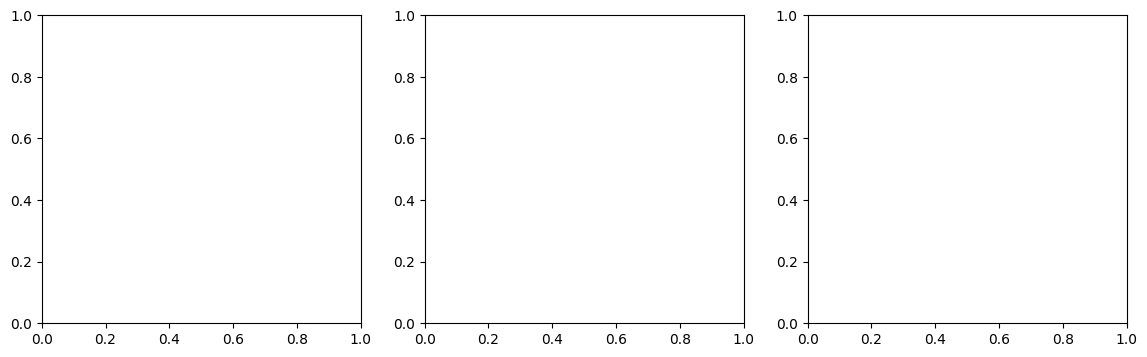

In [60]:
metrics_info = [
    ("cluster_break_rate",   "Cluster Break Rate",   "steelblue"),
    ("edge_cut_rate",        "Edge Cut Rate",         "tomato"),
    ("entity_concentration", "Entity Concentration",  "seagreen"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, (col, title, color) in zip(axes, metrics_info):
    ax.plot(sweep_df["chunk_size"], sweep_df[col], marker="o", color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Chunk size (characters)")
    ax.set_ylabel(col)
    ax.set_xticks(chunk_sizes)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle(
    f"Chunking Metrics vs Chunk Size\n'{doc['meta_info']['title']}' — character-based chunking",
    y=1.02
)
plt.tight_layout()
plt.show()

### Corpus-level average metrics (all train documents, chunk_size=100 chars)

Corpus averages (chunk_size=100 chars):
cluster_break_rate      0.257
edge_cut_rate           0.646
entity_concentration    0.592
dtype: float64


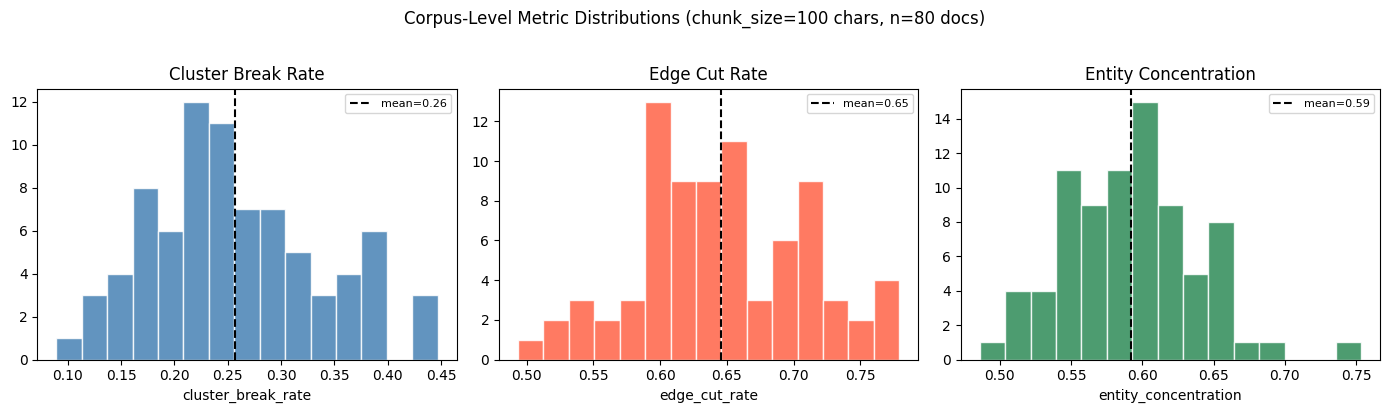

In [43]:
CHUNK_SIZE = 100  # characters

corpus_rows = []
for doc in dataset["train"]:
    r = compute_metrics(doc, CHUNK_SIZE)
    r["title"] = doc["meta_info"]["title"][:35]
    corpus_rows.append(r)

corpus_df = pd.DataFrame(corpus_rows)

print(f"Corpus averages (chunk_size={CHUNK_SIZE} chars):")
print(corpus_df[["cluster_break_rate", "edge_cut_rate", "entity_concentration"]].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, title, color) in zip(axes, metrics_info):
    ax.hist(corpus_df[col], bins=15, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(corpus_df[col].mean(), color="black", linestyle="--",
               label=f"mean={corpus_df[col].mean():.2f}")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle(
    f"Corpus-Level Metric Distributions (chunk_size={CHUNK_SIZE} chars, n={len(corpus_df)} docs)",
    y=1.02
)
plt.tight_layout()
plt.show()